In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

In [23]:
PATH_TO_DATA = "data/titanic"
df = pd.read_csv(f"../{PATH_TO_DATA}/train.csv")

In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.shape

(891, 12)

In [26]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [27]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [28]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
# df["Age"] = df["Age"].fillna(df["Age"].median())

# df["Age"] = df["Age"].fillna(df.groupby(["Sex", "Pclass"])["Age"].transform("median"))

df = df.dropna(subset=['Age'])

df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64

In [30]:
df.shape

(714, 12)

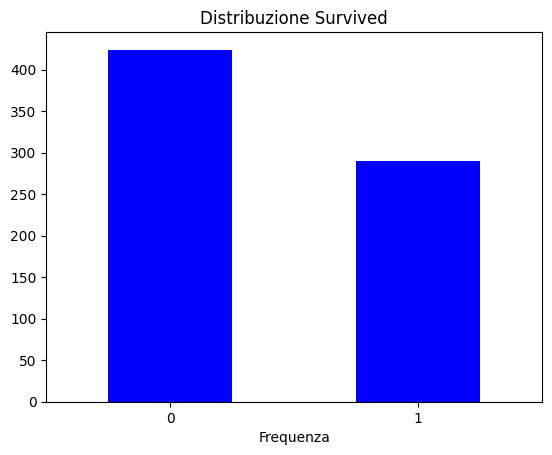

In [31]:
df["Survived"].value_counts().plot(kind="bar", color="blue")
plt.title("Distribuzione Survived")
plt.xlabel("Frequenza")
plt.xticks(rotation=0)
plt.show()

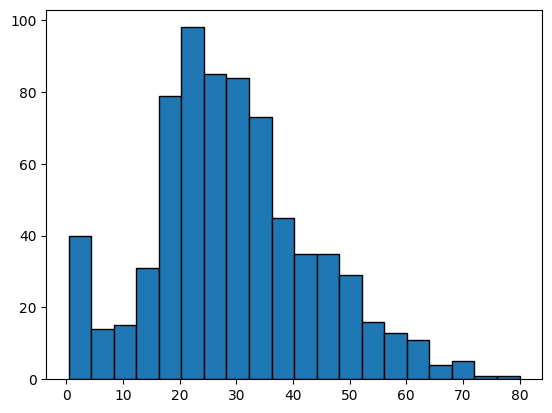

In [32]:
plt.hist(df["Age"], bins="auto", edgecolor="black")
plt.show()

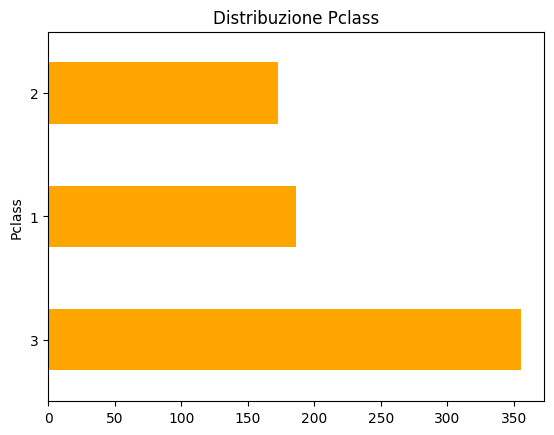

In [33]:
df["Pclass"].value_counts().plot(kind="barh", color="orange")
plt.title("Distribuzione Pclass")
plt.show()

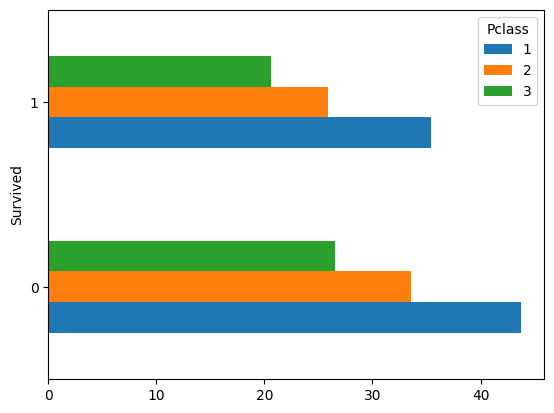

In [34]:
df.groupby(["Survived","Pclass"])["Age"].mean().unstack().plot(kind="barh")
plt.show()

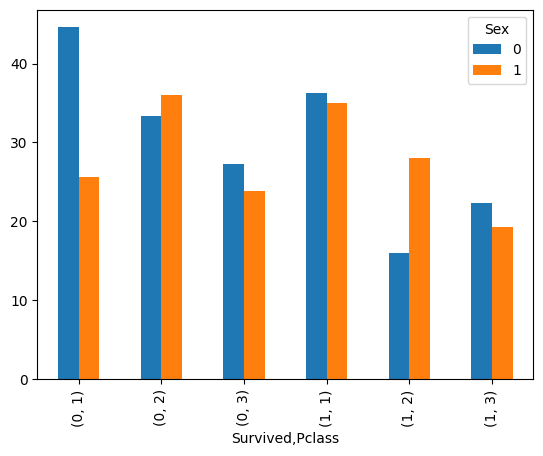

In [35]:
df.groupby(["Survived","Pclass","Sex"])["Age"].mean().unstack().plot(kind="bar")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = ['Sex', 'Pclass', 'Age', 'Fare']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy Logistic Regression: 0.7412587412587412
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



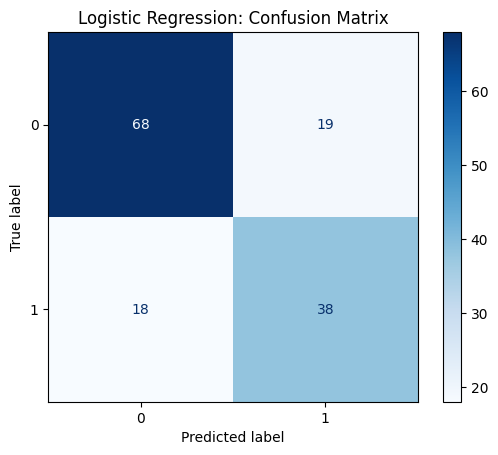

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=0)
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log_reg)).plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression: Confusion Matrix")
plt.show()


Accuracy Decision Tree: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



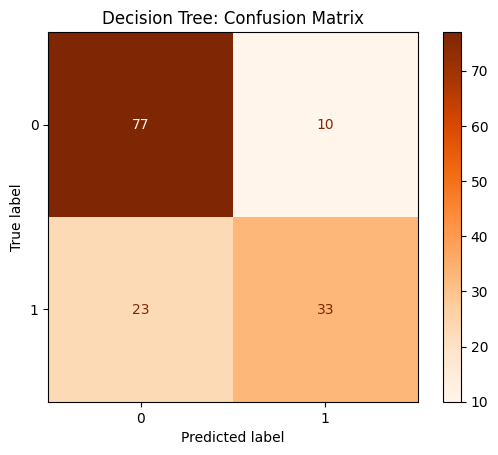

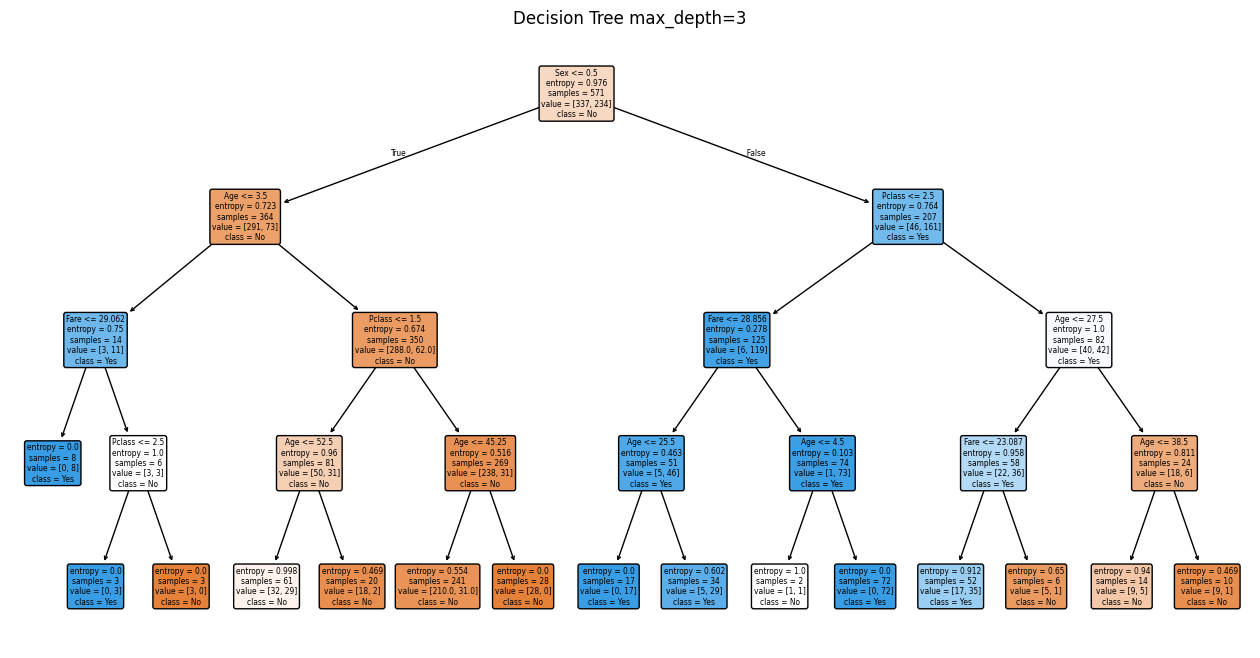

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dec_tree_mod = DecisionTreeClassifier(max_depth=4, random_state=0, min_samples_split=5, min_samples_leaf=2, criterion='entropy')
dec_tree_mod.fit(X_train, y_train)
y_pred_dec_tree = dec_tree_mod.predict(X_test)

print("Accuracy Decision Tree:", accuracy_score(y_test, y_pred_dec_tree))
print(classification_report(y_test, y_pred_log_reg))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dec_tree)).plot(cmap=plt.cm.Oranges)
plt.title("Decision Tree: Confusion Matrix")
plt.show()

plt.figure(figsize=(16,8))
plot_tree(dec_tree_mod, feature_names=features, class_names=["No","Yes"], filled=True, rounded=True)
plt.title("Decision Tree max_depth=3")
plt.show()



Accuracy Random Forest: 0.7902097902097902
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



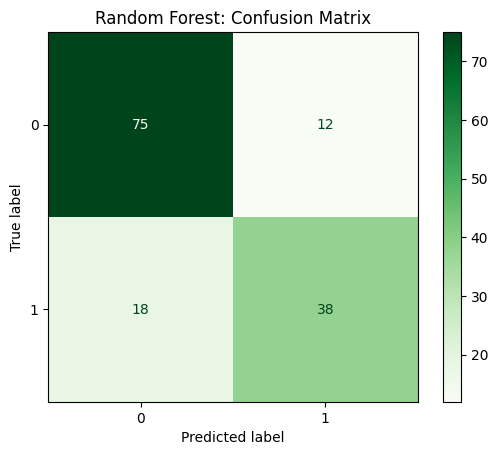

In [39]:
from sklearn.ensemble import RandomForestClassifier

rand_forest_model = RandomForestClassifier(max_depth=4, min_samples_split=5, min_samples_leaf=2, n_estimators=1000, random_state=0)
rand_forest_model.fit(X_train, y_train)
y_pred_rand_forest = rand_forest_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rand_forest))
print(classification_report(y_test, y_pred_log_reg))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rand_forest)).plot(cmap=plt.cm.Greens)
plt.title("Random Forest: Confusion Matrix")
plt.show()


#### K-Nearest Neighbors Classifier

Accuracy KNN: 0.7762237762237763
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



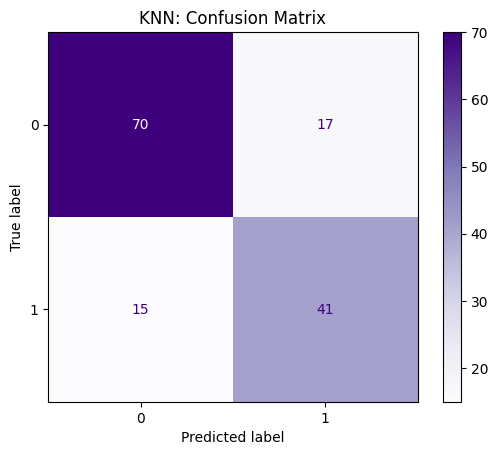

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("Accuracy KNN:", knn_model.score(X_test_scaled, y_test))
print(classification_report(y_test, y_pred_log_reg))

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Purples)
plt.title("KNN: Confusion Matrix")
plt.show()


#### Linear SVC

Accuracy SVC: 0.7412587412587412
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



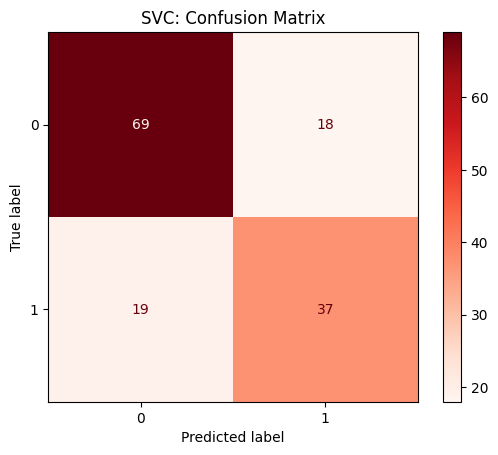

In [41]:
from sklearn.svm import LinearSVC

svc_model = LinearSVC(random_state=0, tol=1e-5)
svc_model.fit(X_train_scaled, y_train)
y_pred_svc = svc_model.predict(X_test_scaled)

print("Accuracy SVC:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_log_reg))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svc)).plot(cmap=plt.cm.Reds)
plt.title("SVC: Confusion Matrix")
plt.show()

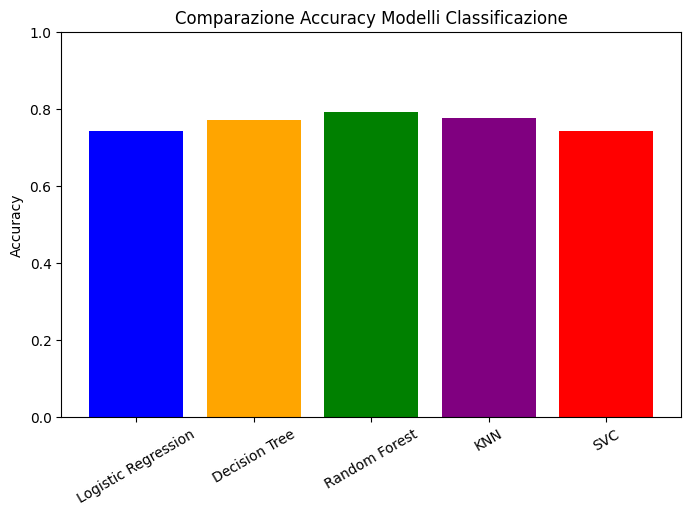

In [42]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log_reg),
    "Decision Tree": accuracy_score(y_test, y_pred_dec_tree),
    "Random Forest": accuracy_score(y_test, y_pred_rand_forest),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVC": accuracy_score(y_test, y_pred_svc)
}

plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue','orange','green','purple','red'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Comparazione Accuracy Modelli Classificazione")
plt.xticks(rotation=30)
plt.show()